In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

rnaseq = pd.read_csv('Datasets/HiSeqV2', sep='\t', index_col=0).T
clinical = pd.read_csv('Datasets/TCGA.BRCA.sampleMap_BRCA_clinicalMatrix', sep='\t')
clinical['label'] = clinical['sample_type'].apply(lambda x: 1 if 'Tumor' in str(x) else 0)
rnaseq.index.name = 'sampleID'
merged = rnaseq.merge(clinical[['sampleID','label']], left_index=True, right_on='sampleID')

X_tcga = merged.drop(['sampleID','label'], axis=1)
y_tcga = merged['label'].values
print("TCGA shape:", X_tcga.shape)

TCGA shape: (1218, 20530)


In [2]:
with open("Datasets/GSE42568_series_matrix.txt", "r") as f:
    for i, line in enumerate(f):
        if i == 46:
            tissue_line = line.strip()
            break

tissue_values = tissue_line.split("\t")[1:]
tissue_values = [v.replace('"','').replace('tissue: ','').strip() for v in tissue_values]
y_geo = np.array([1 if 'cancer' in t.lower() else 0 for t in tissue_values])

gse42568 = pd.read_csv("Datasets/GSE42568_series_matrix.txt",
                        sep="\t", comment="!", index_col=0)
gse42568 = gse42568.dropna(axis=1, how='all').T
print("GSE42568 shape:", gse42568.shape)

GSE42568 shape: (121, 54675)


In [4]:
with open("Datasets/GSE42568_series_matrix.txt", "r") as f:
    for i, line in enumerate(f):
        if i == 46:
            tissue_line = line.strip()
            break

tissue_values = tissue_line.split("\t")[1:]
tissue_values = [v.replace('"','').replace('tissue: ','').strip() for v in tissue_values]
y_train_geo = np.array([1 if 'cancer' in t.lower() else 0 for t in tissue_values])

gse42568 = pd.read_csv("Datasets/GSE42568_series_matrix.txt",
                        sep="\t", comment="!", index_col=0)
gse42568 = gse42568.dropna(axis=1, how='all').T

print("GSE42568 (train) shape:", gse42568.shape)
print("Labels:", dict(zip(*np.unique(y_train_geo, return_counts=True))))

GSE42568 (train) shape: (121, 54675)
Labels: {np.int64(0): np.int64(17), np.int64(1): np.int64(104)}


In [5]:
with open('Datasets/GSE21422_series_matrix.txt', 'r') as f:
    for i, line in enumerate(f):
        if i == 36:
            label_line = line.strip()
            break

label_values = [v.replace('"', '').strip() for v in label_line.split('\t')[1:]]
y_test_geo = np.array([0 if 'healthy' in v.lower() else 1 for v in label_values])

gse21422 = pd.read_csv("Datasets/GSE21422_series_matrix.txt",
                        sep="\t", comment="!", index_col=0)
gse21422 = gse21422.dropna(axis=1, how='all').T

print("GSE21422 (test) shape:", gse21422.shape)
print("Labels:", dict(zip(*np.unique(y_test_geo, return_counts=True))))

GSE21422 (test) shape: (19, 54675)
Labels: {np.int64(0): np.int64(5), np.int64(1): np.int64(14)}


In [6]:
shared_probes = list(set(gse42568.columns.tolist()) & set(gse21422.columns.tolist()))
print("GSE42568 probes:", gse42568.shape[1])
print("GSE21422 probes:", gse21422.shape[1])
print("Shared probes:", len(shared_probes))
# Should be ~54675 — same platform

GSE42568 probes: 54675
GSE21422 probes: 54675
Shared probes: 54675


In [7]:
# Train on GSE42568
X_train = gse42568[shared_probes].values
imputer = SimpleImputer(strategy='median')
X_train_imp = imputer.fit_transform(X_train)
selector = SelectKBest(f_classif, k=100)
X_train_sel = selector.fit_transform(X_train_imp, y_train_geo)

# Test on GSE21422
X_test = gse21422[shared_probes].values
X_test_imp = imputer.transform(X_test)
X_test_sel = selector.transform(X_test_imp)

models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "SVM": SVC(kernel='rbf', random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42)
}

cross_results = {}
for name, model in models.items():
    model.fit(X_train_sel, y_train_geo)
    preds = model.predict(X_test_sel)
    acc = accuracy_score(y_test_geo, preds)
    cross_results[name] = acc
    print(f"\n── {name} ──")
    print(classification_report(y_test_geo, preds, target_names=['Normal','Tumor']))

print("\nCross-dataset accuracies:", cross_results)


── Random Forest ──
              precision    recall  f1-score   support

      Normal       0.26      1.00      0.42         5
       Tumor       0.00      0.00      0.00        14

    accuracy                           0.26        19
   macro avg       0.13      0.50      0.21        19
weighted avg       0.07      0.26      0.11        19


── SVM ──
              precision    recall  f1-score   support

      Normal       0.26      1.00      0.42         5
       Tumor       0.00      0.00      0.00        14

    accuracy                           0.26        19
   macro avg       0.13      0.50      0.21        19
weighted avg       0.07      0.26      0.11        19


── Logistic Regression ──
              precision    recall  f1-score   support

      Normal       0.40      0.80      0.53         5
       Tumor       0.89      0.57      0.70        14

    accuracy                           0.63        19
   macro avg       0.64      0.69      0.61        19
weighted avg   

c:\Users\shaha\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\shaha\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\shaha\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

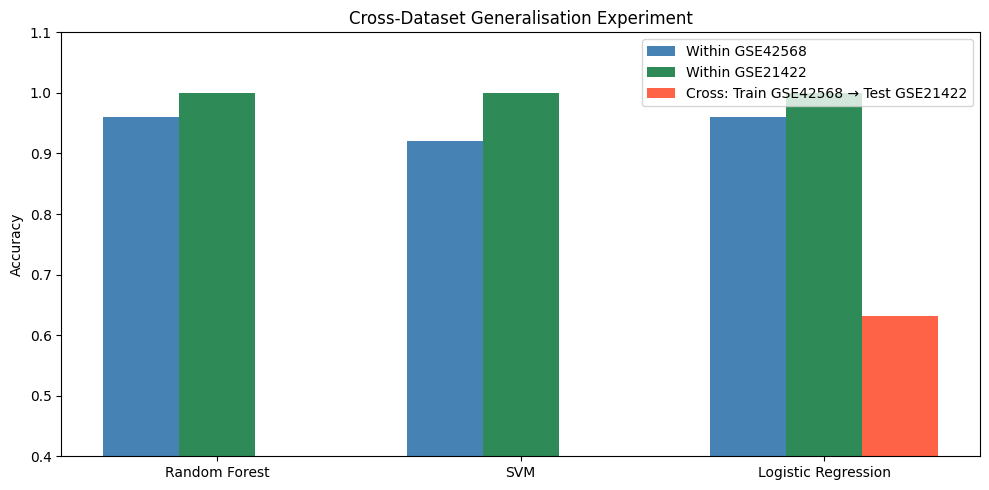

Cross-dataset results: {'Random Forest': 0.2631578947368421, 'SVM': 0.2631578947368421, 'Logistic Regression': 0.631578947368421}


In [9]:
within_gse42568 = {'Random Forest': 0.96, 'SVM': 0.92, 'Logistic Regression': 0.96}
within_gse21422 = {'Random Forest': 1.0,  'SVM': 1.0,  'Logistic Regression': 1.0}

x = np.arange(3)
width = 0.25
labels = list(cross_results.keys())

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - width, [within_gse42568[k] for k in labels],
       width, label='Within GSE42568', color='steelblue')
ax.bar(x,          [within_gse21422[k] for k in labels],
       width, label='Within GSE21422', color='seagreen')
ax.bar(x + width,  [cross_results[k] for k in labels],
       width, label='Cross: Train GSE42568 → Test GSE21422', color='tomato')

ax.set_ylabel('Accuracy')
ax.set_title('Cross-Dataset Generalisation Experiment')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylim(0.4, 1.1)
ax.legend()
plt.tight_layout()
plt.savefig('cross_dataset_comparison.png', dpi=150)
plt.show()

print("Cross-dataset results:", cross_results)